# Decadal hindcast data

Handles onto the cubes, the cached MI, and the null floor. Everything below is loaded, not computed.

In [58]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import infomeasure 

sys.path.insert(0, "../scripts")
import hindcast_handles as H

rc('font', **{'family': 'sans-serif', 'sans-serif':['Helvetica Neue']})
rc('text', usetex=False)

print("%d members x %d start dates, decadal%d..decadal%d (decadal1990 absent), "
      "grid %d x %d, KSG k=%d"
      % (H.N, H.J, H.START[0], H.START[-1], len(H.lats), len(H.lons), H.K))
print("windows    :", H.WINDOWS)
print("null floor : %.4f bits  (pooled permutation null, already computed)" % H.NULL_BITS)

29 members x 45 start dates, decadal1960..decadal2005 (decadal1990 absent), grid 73 x 96, KSG k=5
windows    : ['annual 2-5', 'DJF 2-5', 'DJF 1']
null floor : 0.0503 bits  (pooled permutation null, already computed)


In [6]:
WINDOW = "annual 2-5"            # Eade et al.: four-year mean over lead years 2-5
                                 # also "DJF 2-5", "DJF 1"

F, G = H.FIELDS[WINDOW]          # (N, J, lat, lon) members, (J, lat, lon) obs
s = F.mean(axis=0)               # (J, lat, lon)    ensemble mean
                                 # all detrended along the start-date axis, in Pa

lats, lons, W = H.lats, H.lons, H.W
START, WINTER = H.START, H.WINTER

for _n, _a in [("F", F), ("G", G), ("s", s), ("MI_M", MI_M), ("MI_O", MI_O),
               ("MI_SG", MI_SG), ("lats", lats), ("lons", lons), ("W", W)]:
    print("%-6s %s" % (_n, _a.shape))

F      (29, 45, 73, 96)
G      (45, 73, 96)
s      (45, 73, 96)
MI_M   (29, 73, 96)
MI_O   (29, 73, 96)
MI_SG  (73, 96)
lats   (73,)
lons   (96,)
W      (73, 96)


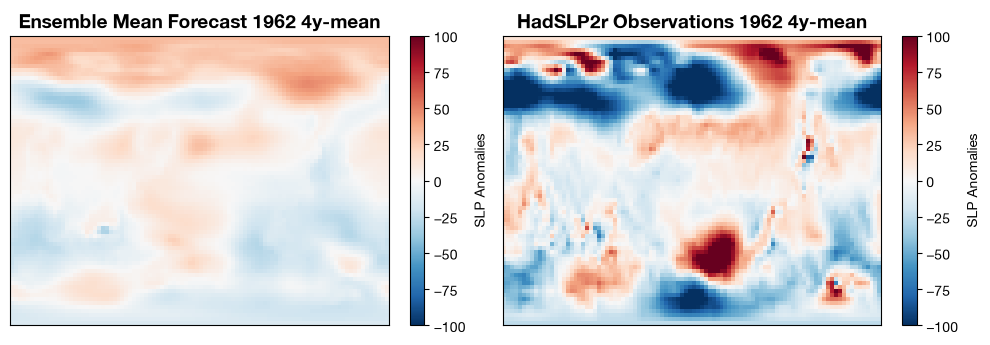

In [19]:
# See snapshots for comparison
YR_IDX = 2

COLOR_SCALE=100

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(s[YR_IDX, :, :], clim=[-COLOR_SCALE, COLOR_SCALE], cmap='RdBu_r')
im1 = axs[1].imshow(G[YR_IDX, :, :], clim=[-COLOR_SCALE, COLOR_SCALE], cmap='RdBu_r')
fig.colorbar(im1, ax=axs[1], fraction=0.035, label='SLP Anomalies')
fig.colorbar(im1, ax=axs[0], fraction=0.035, label='SLP Anomalies')

for i in range(2):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
axs[0].set_title(f'Ensemble Mean Forecast {H.START[YR_IDX]} 4y-mean', fontweight=700, fontsize=14) 
axs[1].set_title(f'HadSLP2r Observations {H.START[YR_IDX]} 4y-mean', fontweight=700, fontsize=14) 
plt.tight_layout()

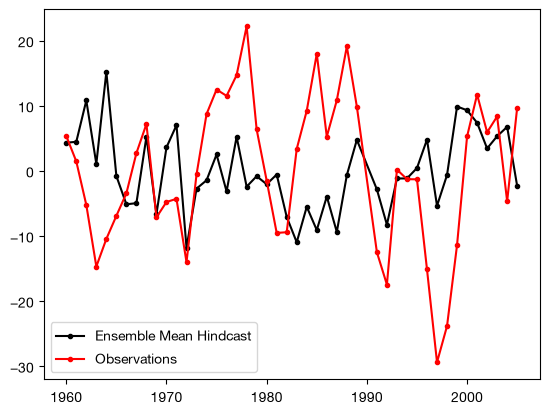

In [53]:
# Build a box and area-average within it
a1, a2 = 40, 50
b1, b2 = 30, 50

s_t = np.mean(s[:, a1:a2, b1:b2], axis=(1,2))
G_t = np.mean(G[:, a1:a2, b1:b2], axis=(1,2))

plt.plot(H.START, s_t, 'k.-')
plt.plot(H.START, G_t, 'r.-');
plt.legend(['Ensemble Mean Hindcast', 'Observations'])

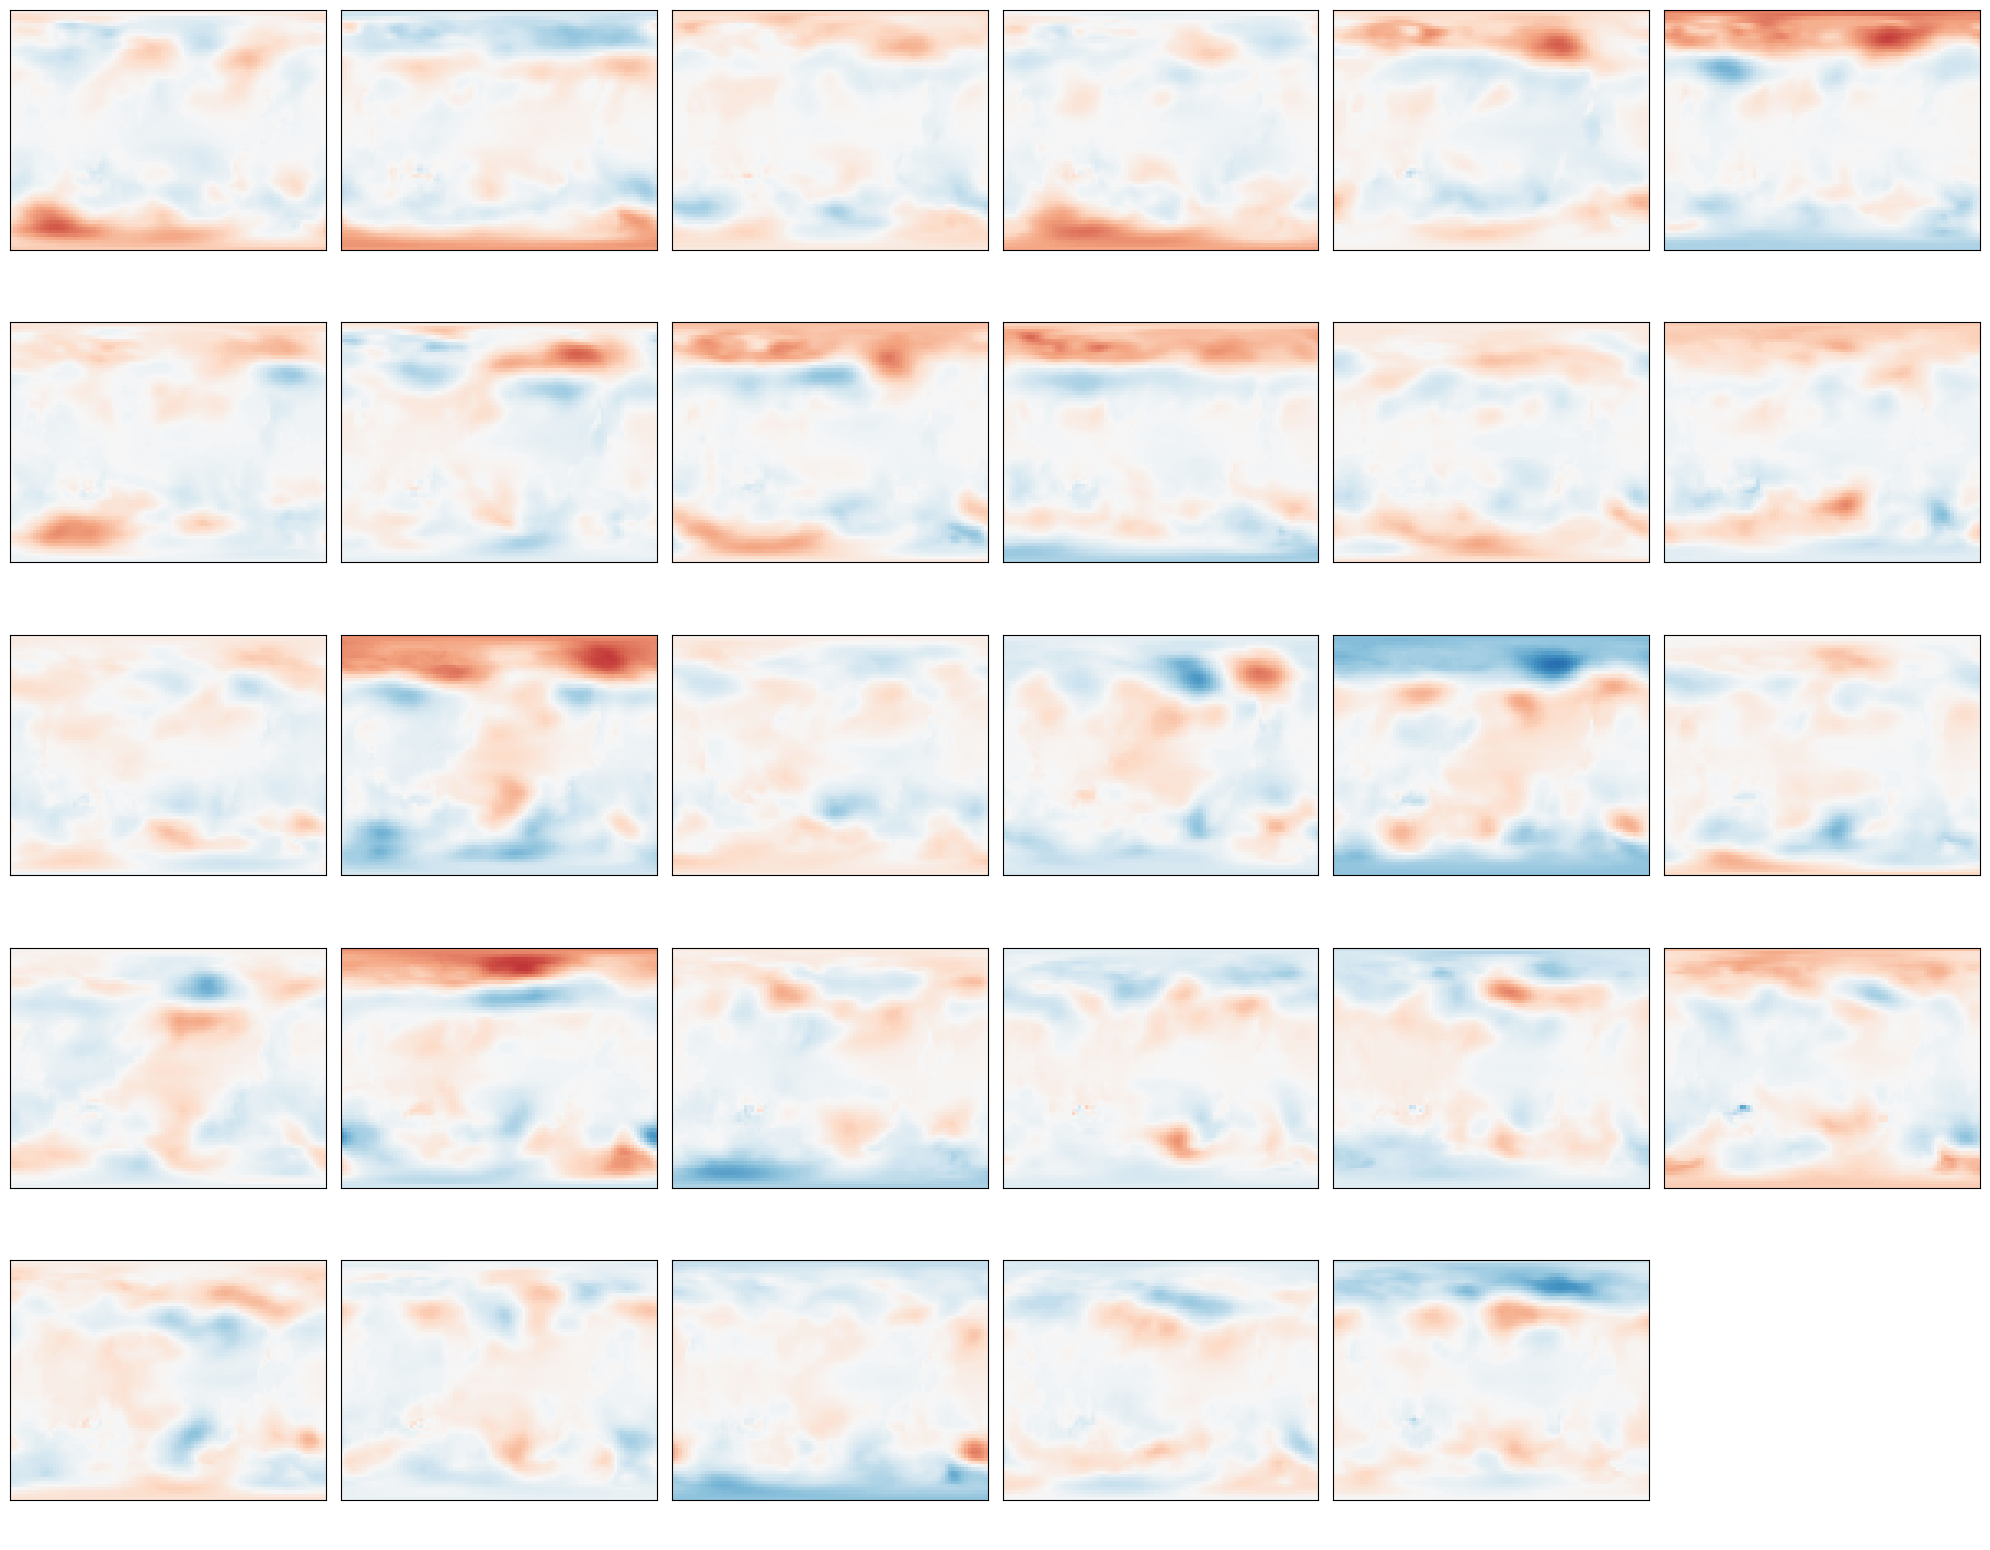

In [33]:
YR_IDX = 2

fig, axs = plt.subplots(5, 6, figsize=(20, 16))
axs=axs.flatten()

for i in range(len(axs)):
    if i < F.shape[0]:
        axs[i].imshow(F[i, YR_IDX, :, :], clim=[-500, 500], cmap='RdBu_r')
    else:
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['left'].set_visible(False)
        axs[i].spines['bottom'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])


plt.tight_layout()

In [43]:
def pearson_coeff(s, G):
    num = np.mean((s - np.mean(s, axis=0)) * (G - np.mean(G, axis=0)))
    den = np.std(s, axis=0) * np.std(G, axis=0)
    return num/den 

def ensemble_SNR(F):
    s = np.mean(F, axis=0)
    noise = np.mean(np.std(F, axis=1), axis=0)
    return np.std(s, axis=0) / noise

Text(0.5, 1.0, '$\\rho=\\rho_o/\\rho_m$')

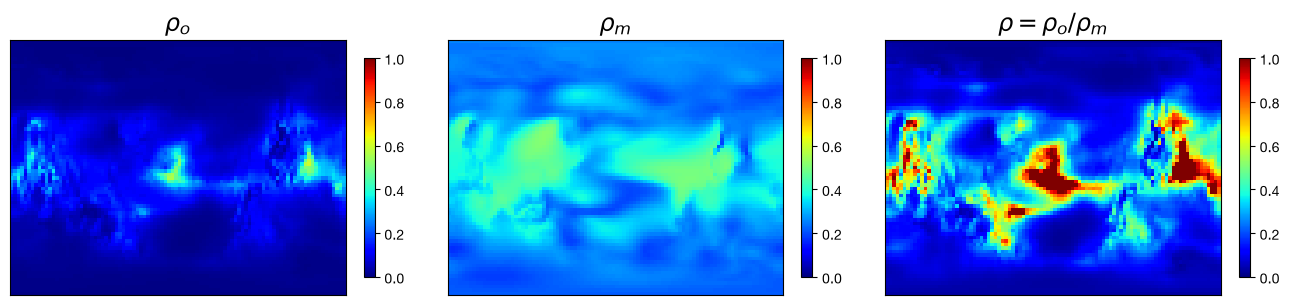

In [55]:
rho_o = pearson_coeff(s, G)
rho_m = ensemble_SNR(F) 

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
im0 = axs[0].imshow(rho_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(rho_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(rho_o / rho_m, cmap='jet', vmin=0, vmax=1)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\rho_o$', fontsize=17)
axs[1].set_title('$\\rho_m$', fontsize=17)
axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

In [91]:
def calc_MI_sG(s, G, k=4):
    _, m, n = s.shape
    MI_sG = np.nan * np.ones((m,n))
    for i in range(m):
        for j in range(n):
            MI_sG[i, j] = infomeasure.mutual_information(s[:,i,j], G[:,i,j], approach='metric', k=k)
    return MI_sG 
from joblib import Parallel, delayed


def calc_MI_sF(F, k=4, n_jobs=-1):
    """
    F: shape (N, T, m, n)
    """

    N, T, m, n = F.shape
    F2 = np.ascontiguousarray(F.reshape(N, T, -1))
    Fsum = F2.sum(axis=0)  # (T, space)

    def calc_point(p):
        fp = F2[:, :, p]       # (N, T)
        total = Fsum[:, p]     # (T,)
        vals = np.empty(N)

        for member in range(N):
            x = fp[member]
            # Exact mean of all OTHER N-1 members
            loo_s = (total - x) / (N - 1)
            vals[member] = infomeasure.mutual_information(loo_s, x, approach="metric", k=k)
        return vals.mean()

    result = Parallel(n_jobs=n_jobs, backend="loky", batch_size="auto",)(
        delayed(calc_point)(p)
        for p in range(m * n)
    )
    return np.asarray(result).reshape(m, n)

In [110]:
MIsG_k1 = calc_MI_sG(s, G, k=1)

MIsG_k3 = calc_MI_sG(s, G, k=3)
MIsG_k4 = calc_MI_sG(s, G, k=4)
# MIsG_k5 = calc_MI_sG(s, G, k=5)

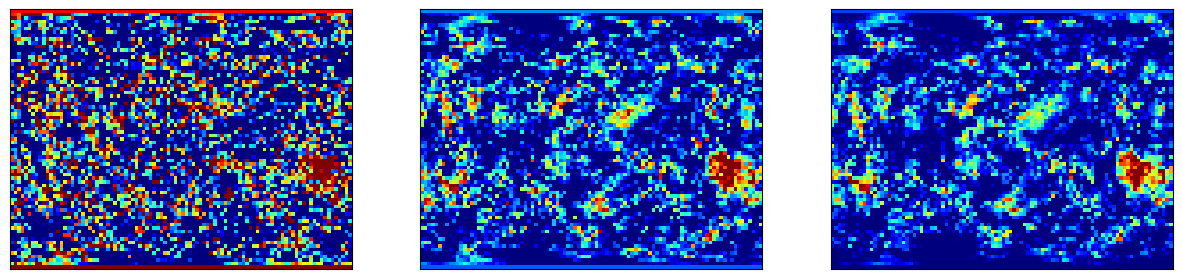

In [111]:
VMIN, VMAX = 0, 0.3
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(MIsG_k1, vmin=VMIN, vmax=VMAX, cmap='jet')
axs[1].imshow(MIsG_k3, vmin=VMIN, vmax=VMAX, cmap='jet')
axs[2].imshow(MIsG_k4, vmin=VMIN, vmax=VMAX, cmap='jet')

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

In [94]:
MIsF_k3 = calc_MI_sF(F, k=3)
MIsF_k4 = calc_MI_sF(F, k=4)
MIsF_k5 = calc_MI_sF(F, k=5)


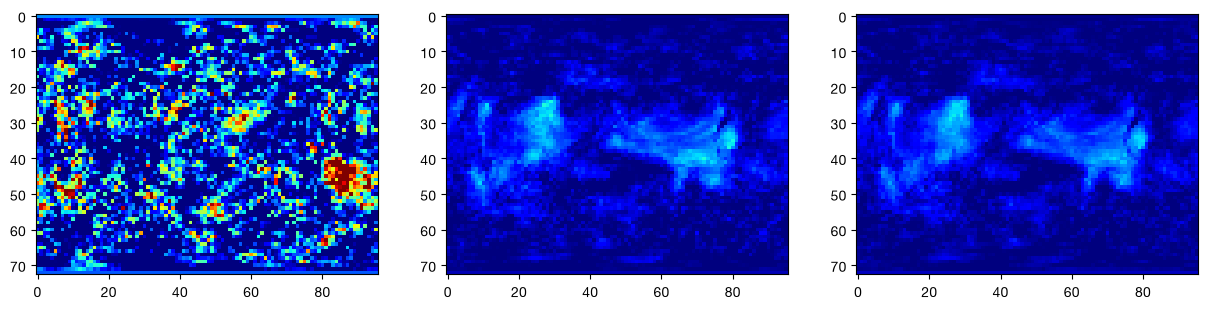

In [95]:
VMIN, VMAX = 0, 0.3
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(MIsG_k3, vmin=VMIN, vmax=VMAX, cmap='jet')
axs[1].imshow(MIsF_k4, vmin=VMIN, vmax=VMAX, cmap='jet')
axs[2].imshow(MIsF_k5, vmin=VMIN, vmax=VMAX, cmap='jet')


In [107]:
lam_of = lambda I: np.sqrt(1 - np.exp(-2*np.maximum(I, 0)) + 1e-6)

lam_o = lam_of(MIsG_k4)
lam_m = lam_of(MIsF_k4)

Text(0.5, 1.0, '$\\rho=\\rho_o/\\rho_m$')

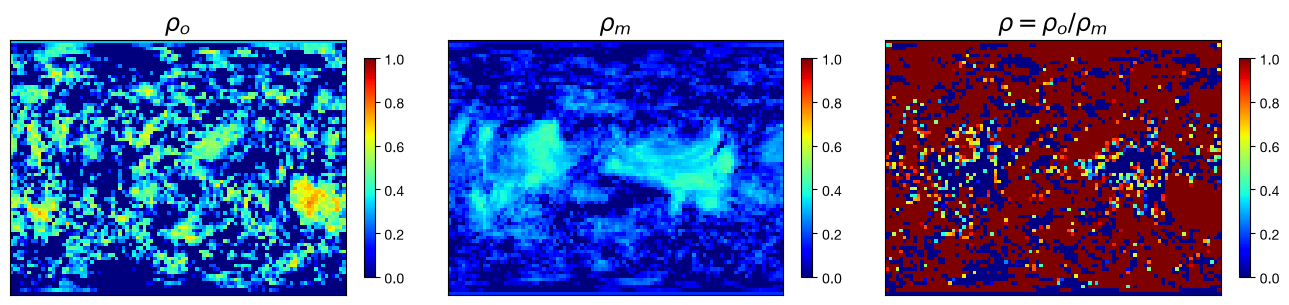

In [108]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
im0 = axs[0].imshow(lam_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(lam_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(lam_o / lam_m, cmap='jet', vmin=0, vmax=1)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\rho_o$', fontsize=17)
axs[1].set_title('$\\rho_m$', fontsize=17)
axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

In [ ]:
rho_pair = H.rho_pair            # Pearson along axis 0, vectorised over the grid
lam = H.lam                      # sqrt(1 - 2^-2I); I must be in BITS
excess = H.excess                # raw MI minus the null floor -- apply BEFORE lam()
gm = H.gm                        # cos(lat)-weighted global mean, NaNs skipped
loo_mean = H.loo_mean            # s_-n from the (N, J, lat, lon) member stack

PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180      # grid is 0..356.25E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=12)
    return h


print("ready:", ", ".join(["rho_pair", "lam", "excess", "gm", "loo_mean", "panel"]))

## scratch